# train_dynamic_rl.py

In [ ]:
# Обучение динамических RL-агентов (PolicyGradient, EnhancedPolicyGradient, ImprovedDQN, ImprovedDoubleDQN) на быстрой динамической среде ATSP.
# Используются готовые матрицы времени (time_matrices.zip).
# Каждый агент обучается 1500 эпизодов, сохраняются:
# - лучшая и финальная модели,
# - метрики обучения (время, расстояние, стабильность, сходимость),
# - кривая обучения и архив.
import os
import json
import zipfile
import shutil
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

# Импортируем динамических агентов
from dynamic_rl_agents import (
    DynamicPolicyGradientAgent,
    DynamicEnhancedPolicyGradientAgent,
    DynamicImprovedDQNAgent,
    DynamicImprovedDoubleDQNAgent
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {DEVICE}")

Устройство: cuda


In [ ]:
# 0. Распаковка архивов и загрузка матриц времени
def unzip_all(archives, extract_to):
    for archive in archives:
        if not os.path.exists(archive):
            print(f"Архив {archive} не найден, пропускаем.")
            continue
        with zipfile.ZipFile(archive, 'r') as zf:
            zf.extractall(extract_to)
        print(f"Распакован {archive} в {extract_to}")

def ensure_data_available():
    # Архивы, которые уже содержат папку внутри
    data_archives = ["raw_data.zip"]
    # Архивы, которые нужно распаковать в отдельную папку
    model_archives = ["time_matrices.zip"]

    for archive in data_archives:
        if os.path.exists(archive):
            print(f"Распаковываем {archive} в текущую папку")
            unzip_all([archive], extract_to=".")
        else:
            print(f"Архив {archive} не найден, пропускаем.")

    for archive in model_archives:
        if os.path.exists(archive):
            folder_name = archive.replace('.zip', '')
            os.makedirs(folder_name, exist_ok=True)
            print(f"Распаковываем {archive} в {folder_name}/")
            unzip_all([archive], extract_to=folder_name)
        else:
            print(f"Архив {archive} не найден, пропускаем.")

ensure_data_available()

Распаковываем raw_data.zip в текущую папку
Распакован raw_data.zip в .
Распаковываем time_matrices.zip в time_matrices/
Распакован time_matrices.zip в time_matrices


In [ ]:
# Загрузка матриц времени
scenario_names = ["Без_шума", "Пробки", "Блокировки+Пробки", "Умеренные_условия"]
time_matrices = {}
for scenario in scenario_names:
    fname = os.path.join("time_matrices", f"time_matrix_{scenario}.npy")
    if not os.path.exists(fname):
        raise FileNotFoundError(f"Отсутствует файл матрицы времени: {fname}")
    time_matrices[scenario] = np.load(fname)
    print(f"Матрица времени '{scenario}' загружена, размер: {time_matrices[scenario].shape}")

n_nodes = time_matrices[scenario_names[0]].shape[0]
print(f"Количество складов: {n_nodes}")


Матрица времени 'Без_шума' загружена, размер: (12, 12)
Матрица времени 'Пробки' загружена, размер: (12, 12)
Матрица времени 'Блокировки+Пробки' загружена, размер: (12, 12)
Матрица времени 'Умеренные_условия' загружена, размер: (12, 12)
Количество складов: 12


In [ ]:
# 1. Временной профиль и быстрая динамическая среда
def scenario_for_hour(hour):
    if 23 <= hour or hour < 6:   return "Без_шума"
    elif 6 <= hour < 8:          return "Умеренные_условия"
    elif 8 <= hour < 11:         return "Пробки"
    elif 11 <= hour < 17:        return "Умеренные_условия"
    elif 17 <= hour < 20:        return "Блокировки+Пробки"
    elif 20 <= hour < 21:        return "Пробки"
    else:                        return "Умеренные_условия"

class FastDynamicTrainingEnv:
    """
    Быстрая динамическая среда, использующая готовые матрицы времени.
    Награда = -время_поездки (часы). Расстояние аппроксимируется как время * 60 км/ч.
    """
    def __init__(self, time_matrices, n_nodes, start_time=6.0):
        self.time_matrices = time_matrices
        self.n = n_nodes
        self.start_time = start_time
        self.current_time = start_time
        self.current_node = 0
        self.visited = [False] * n_nodes
        self.visited[0] = True
        self.route = [0]
        self.total_time_h = 0.0
        self.total_distance_km = 0.0
        self.log = []

    def _current_matrix(self):
        hour = int(self.current_time)
        scenario = scenario_for_hour(hour)
        return self.time_matrices[scenario]

    def step(self, action):
        if self.visited[action]:
            return -1e6, 0.0, True   # невалидное действие
        mat = self._current_matrix()
        t = mat[self.current_node, action]
        if np.isinf(t):
            return -1e6, 0.0, True

        dist_km = t * 60.0  # приблизительное расстояние

        self.total_time_h += t
        self.total_distance_km += dist_km
        self.current_time += t
        self.current_node = action
        self.visited[action] = True
        self.route.append(action)

        done = all(self.visited)
        if done:
            t_ret = mat[self.current_node, 0]
            if np.isinf(t_ret):
                return -1e6, 0.0, True
            self.total_time_h += t_ret
            self.total_distance_km += t_ret * 60.0
            self.route.append(0)

        return -t, dist_km, done

    def get_state(self):
        mat = self._current_matrix()
        time_vector = mat[self.current_node, :].copy()
        visited_mask = np.array(self.visited, dtype=np.float32)
        return time_vector, visited_mask, self.current_node

    def reset(self):
        self.current_time = self.start_time
        self.current_node = 0
        self.visited = [False] * self.n
        self.visited[0] = True
        self.route = [0]
        self.total_time_h = 0.0
        self.total_distance_km = 0.0
        self.log = []

In [ ]:
# 2. Функция обучения одного агента
def train_rl_agent(agent, agent_name, num_episodes=1500, save_dir="dynamic_rl_models"):
    os.makedirs(save_dir, exist_ok=True)
    start_time = time.time()

    best_time = float('inf')
    best_dist = 0.0
    best_ep = 0
    episode_times = []
    episode_distances = []
    pbar = tqdm(range(num_episodes), desc=agent_name)

    for ep in pbar:
        env = FastDynamicTrainingEnv(time_matrices, n_nodes, start_time=6.0)
        time_vector, visited_mask, current = env.get_state()
        done = False

        while not done:
            # Выбор действия
            if isinstance(agent, (DynamicImprovedDQNAgent, DynamicImprovedDoubleDQNAgent)):
                action = agent.select_action(current, visited_mask, time_vector, greedy=False)
            else:
                action = agent.select_action(current, visited_mask, time_vector)

            reward, dist_km, done = env.step(action)
            next_time_vector, next_visited_mask, next_current = env.get_state()

            # Сохраняем опыт для off-policy агентов
            if hasattr(agent, 'store_experience'):
                agent.store_experience(
                    (current, visited_mask, time_vector),
                    action, reward,
                    (next_current, next_visited_mask, next_time_vector),
                    done
                )
                # Выполняем шаг обучения
                agent.update()

            # Накапливаем награду для on-policy агентов
            if hasattr(agent, 'rewards'):
                agent.rewards.append(reward)

            current, visited_mask, time_vector = next_current, next_visited_mask, next_time_vector

        # Конец эпизода: обновляем on-policy агента
        if hasattr(agent, 'update') and not hasattr(agent, 'store_experience'):
            agent.update()

        total_time = env.total_time_h
        total_dist = env.total_distance_km
        episode_times.append(total_time)
        episode_distances.append(total_dist)

        # Сохраняем лучшую модель
        if total_time < best_time:
            best_time = total_time
            best_dist = total_dist
            best_ep = ep + 1
            torch.save(agent, os.path.join(save_dir, f"{agent_name}_best.pt"))

        if (ep+1) % 100 == 0:
            avg100 = np.mean(episode_times[-100:]) if len(episode_times) >= 100 else np.mean(episode_times)
            pbar.set_postfix(best=f"{best_time:.2f}h", avg100=f"{avg100:.2f}h")

    # Сохраняем финальную модель
    training_time = time.time() - start_time
    torch.save(agent, os.path.join(save_dir, f"{agent_name}_final.pt"))

    # 3. Метрики
    avg_last_100 = np.mean(episode_times[-100:]) if len(episode_times) >= 100 else np.mean(episode_times)
    std_last_100 = np.std(episode_times[-100:]) if len(episode_times) >= 100 else 0.0
    # Эпизод сходимости
    conv_ep = len(episode_times)
    for i, t in enumerate(episode_times):
        if t <= best_time * 1.01:
            conv_ep = i + 1
            break

    metrics = {
        "agent": agent_name,
        "episodes": num_episodes,
        "best_time_h": best_time,
        "best_distance_km": best_dist,
        "best_episode": best_ep,
        "final_time_h": episode_times[-1],
        "final_distance_km": episode_distances[-1],
        "mean_last_100_time": avg_last_100,
        "std_last_100_time": std_last_100,
        "convergence_episode": conv_ep,
        "training_time_sec": training_time
    }
    with open(os.path.join(save_dir, f"{agent_name}_metrics.json"), "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)
    print(f"Метрики сохранены: {save_dir}/{agent_name}_metrics.json")

    # График обучения
    plt.figure(figsize=(10,5))
    plt.plot(episode_times, alpha=0.5, label='Episode time')
    if len(episode_times) >= 100:
        ma = np.convolve(episode_times, np.ones(100)/100, mode='valid')
        plt.plot(range(99, len(episode_times)), ma, label='MA 100')
    plt.xlabel('Episode')
    plt.ylabel('Total time (h)')
    plt.title(f'Training {agent_name} (Dynamic ATSP)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"{agent_name}_learning_curve.png"))
    plt.show()

    return episode_times, best_time

Обучение DynamicPolicyGradient (12 складов)


DynamicPolicyGradient:   0%|          | 0/1500 [00:00<?, ?it/s]/content/dynamic_rl_agents.py:55: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  vis_t = torch.tensor([visited_mask], dtype=torch.float32, device=DEVICE)
DynamicPolicyGradient: 100%|██████████| 1500/1500 [00:37<00:00, 39.72it/s, avg100=18.42h, best=12.73h]


Метрики сохранены: dynamic_rl_models/DynamicPolicyGradient/DynamicPolicyGradient_metrics.json


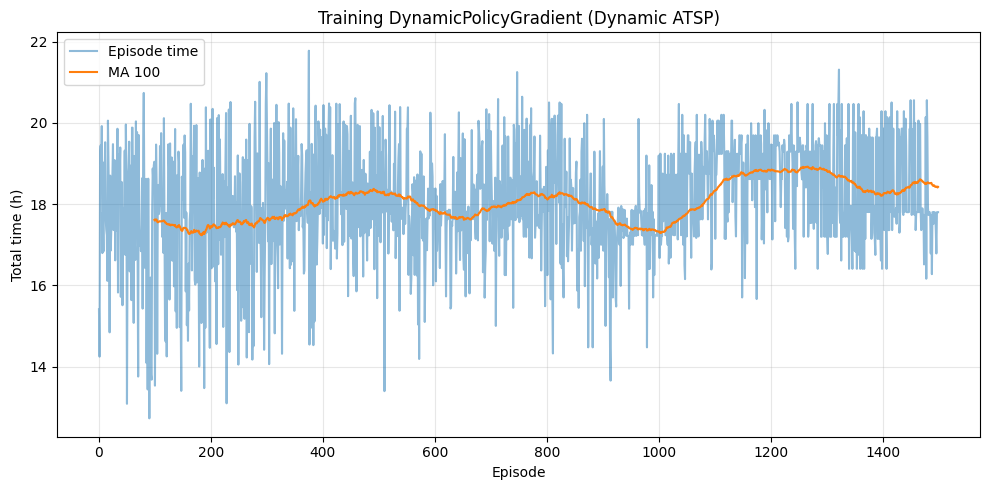

Обучение DynamicEnhancedPolicyGradient (12 складов)


DynamicEnhancedPolicyGradient: 100%|██████████| 1500/1500 [00:49<00:00, 30.13it/s, avg100=14.21h, best=10.95h]


Метрики сохранены: dynamic_rl_models/DynamicEnhancedPolicyGradient/DynamicEnhancedPolicyGradient_metrics.json


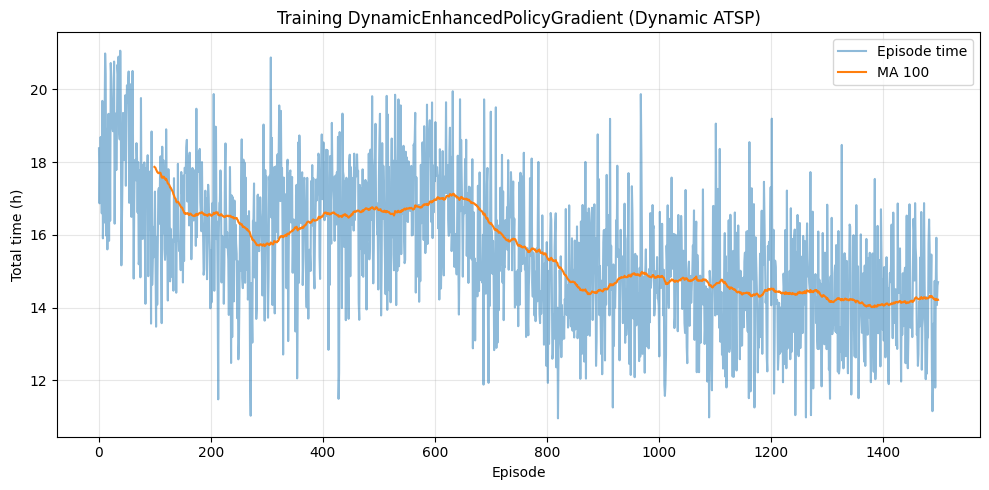

Обучение DynamicImprovedDQN (12 складов)


DynamicImprovedDQN: 100%|██████████| 1500/1500 [02:38<00:00,  9.49it/s, avg100=9.24h, best=9.13h]


Метрики сохранены: dynamic_rl_models/DynamicImprovedDQN/DynamicImprovedDQN_metrics.json


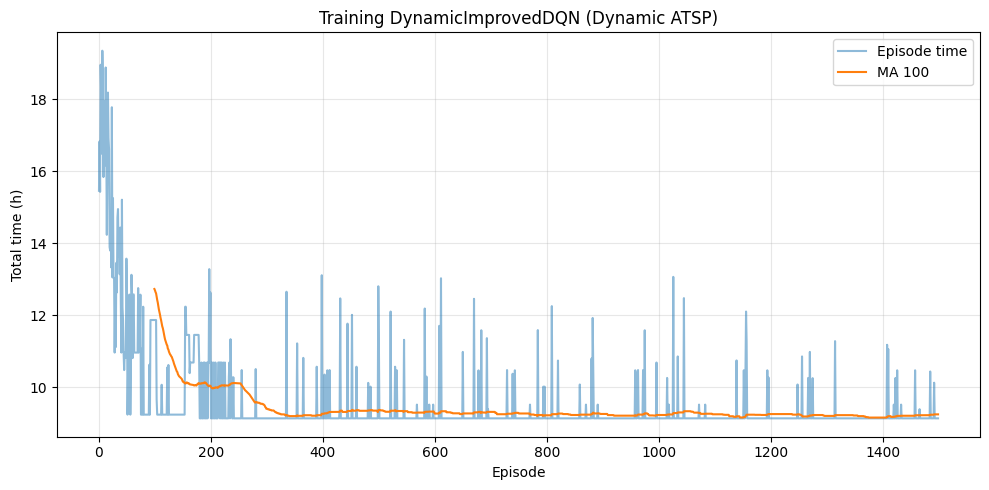

Обучение DynamicImprovedDoubleDQN (12 складов)


DynamicImprovedDoubleDQN: 100%|██████████| 1500/1500 [03:16<00:00,  7.63it/s, avg100=9.26h, best=9.13h]


Метрики сохранены: dynamic_rl_models/DynamicImprovedDoubleDQN/DynamicImprovedDoubleDQN_metrics.json


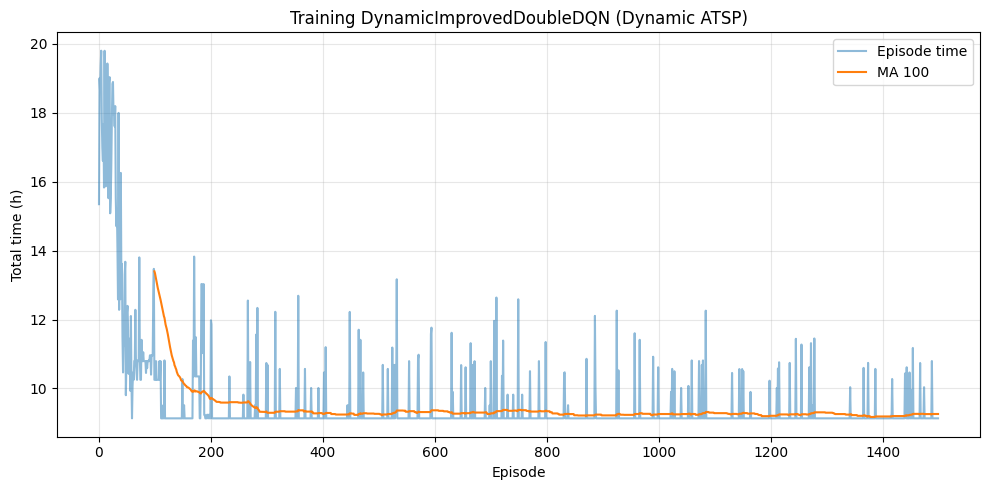

Архив создан: dynamic_rl_models/DynamicPolicyGradient.zip
Архив создан: dynamic_rl_models/DynamicEnhancedPolicyGradient.zip
Архив создан: dynamic_rl_models/DynamicImprovedDQN.zip
Архив создан: dynamic_rl_models/DynamicImprovedDoubleDQN.zip

Обучение всех динамических RL-агентов завершено


In [ ]:
# 4. Основной блок – обучаем всех агентов
if __name__ == "__main__":
    AGENT_CLASSES = {
        "DynamicPolicyGradient": DynamicPolicyGradientAgent,
        "DynamicEnhancedPolicyGradient": DynamicEnhancedPolicyGradientAgent,
        "DynamicImprovedDQN": DynamicImprovedDQNAgent,
        "DynamicImprovedDoubleDQN": DynamicImprovedDoubleDQNAgent,
    }

    base_save_dir = "dynamic_rl_models"
    os.makedirs(base_save_dir, exist_ok=True)
    all_save_dirs = []

    for agent_name, agent_cls in AGENT_CLASSES.items():
        print(f"Обучение {agent_name} ({n_nodes} складов)")

        agent = agent_cls(n_nodes)
        agent_save_dir = os.path.join(base_save_dir, agent_name)
        all_save_dirs.append(agent_save_dir)

        train_rl_agent(
            agent=agent,
            agent_name=agent_name,
            num_episodes=1500,
            save_dir=agent_save_dir
        )

    # Архивируем папки каждого агента
    for d in all_save_dirs:
        shutil.make_archive(d, 'zip', d)
        print(f"Архив создан: {d}.zip")

    print("\nОбучение всех динамических RL-агентов завершено")